#ML FINAL EXAM

### Email: ammarhamim7@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [47]:
df=pd.read_csv("/content/breast_cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [49]:
df.shape

(569, 33)

## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:

I selected the Breast Cancer Dataset because it is a well-known and widely used dataset for binary classification problems. The dataset is used to predict whether a breast tumor is malignant (cancerous) or benign (non-cancerous) based on different medical measurements. its ideal for classification algorithms.

### Observation

1. Dataset has 569 samples with 33 columns
2. The target variable has two classes: Malignant(M),Benign(B)
3. Mostly numerical columns

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [50]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes.value_counts())

(569, 33)
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      

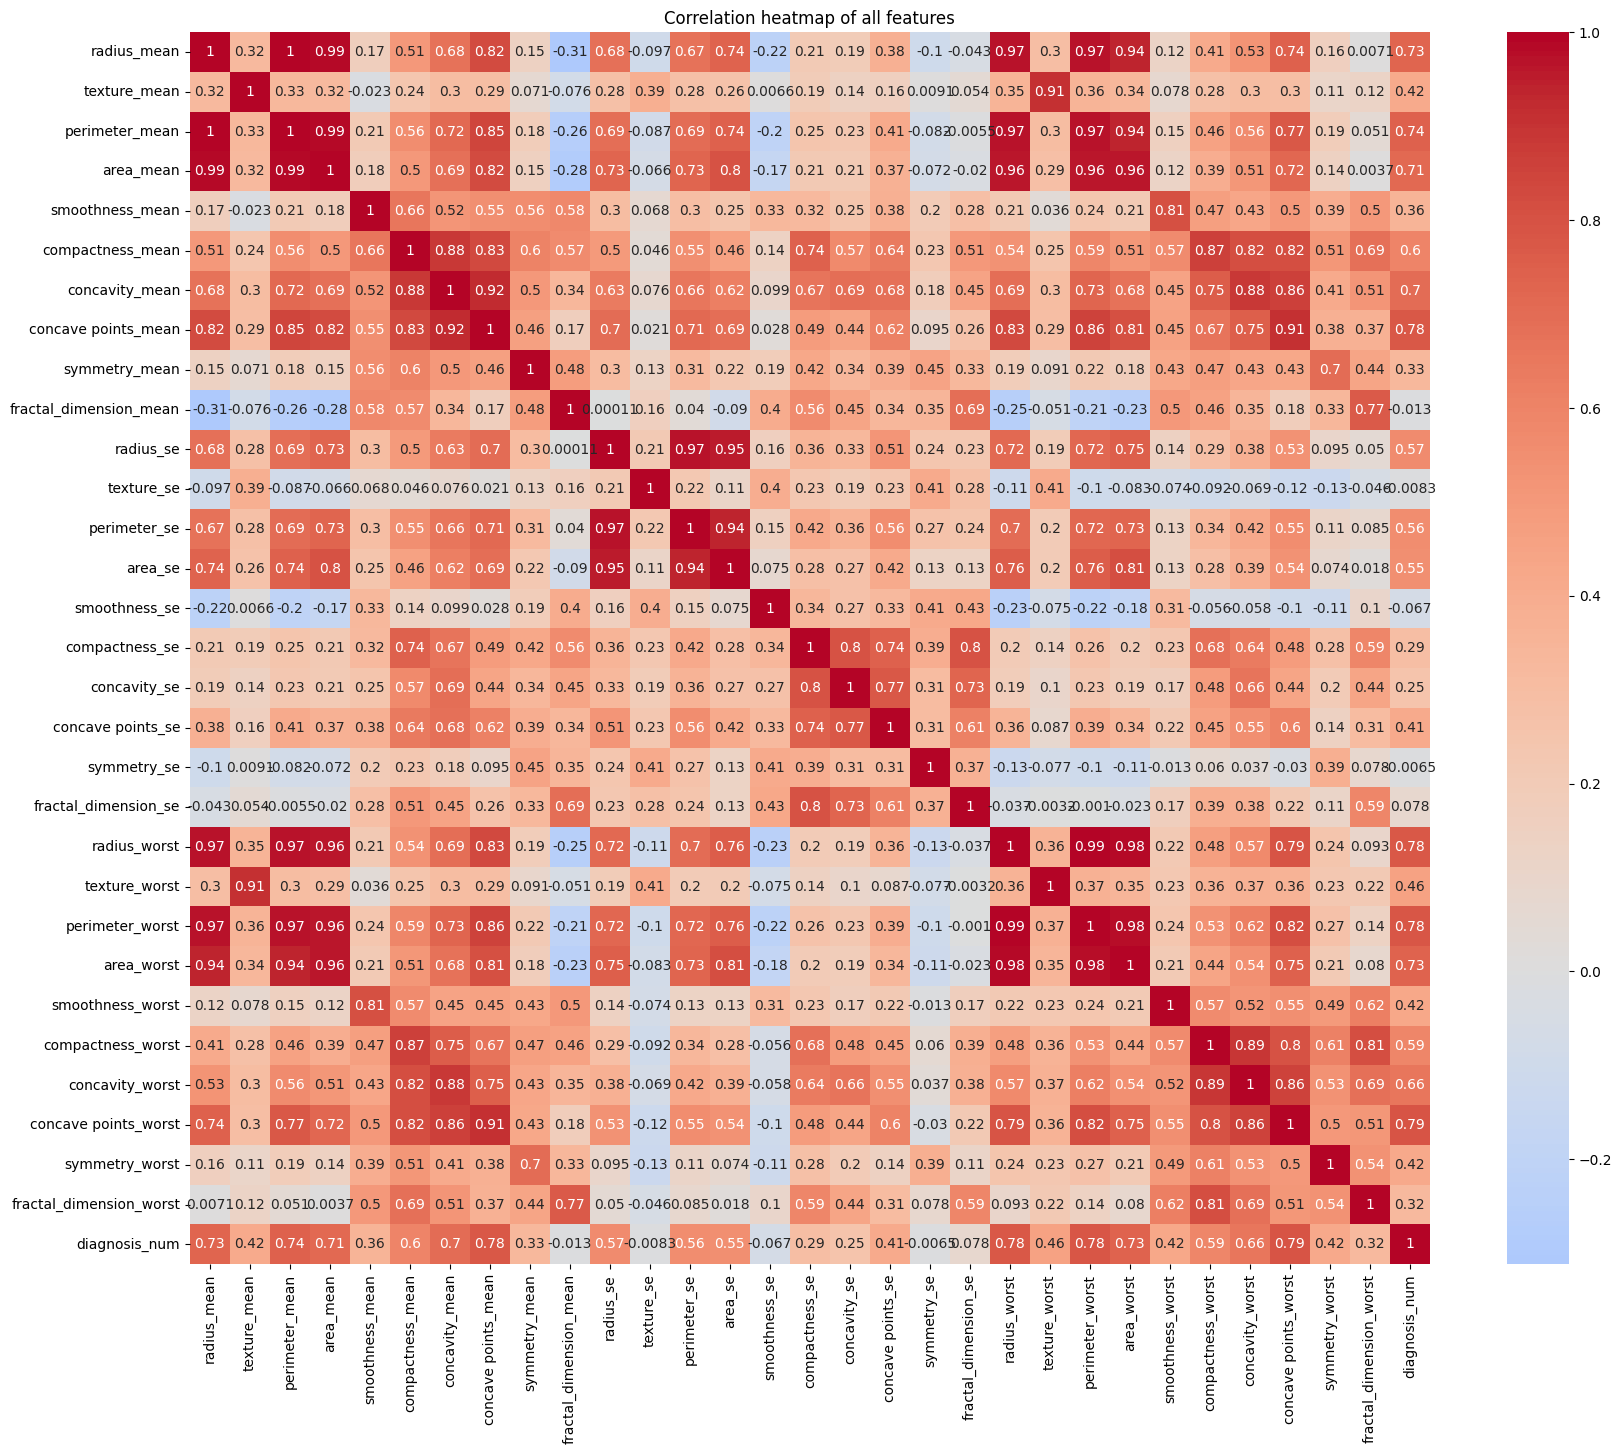

In [51]:
df_corr = df.drop(columns=['id', 'Unnamed: 32'])
df_corr['diagnosis_num'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})
corr = df_corr.drop(columns=['diagnosis']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title('Correlation heatmap of all features')
plt.show()

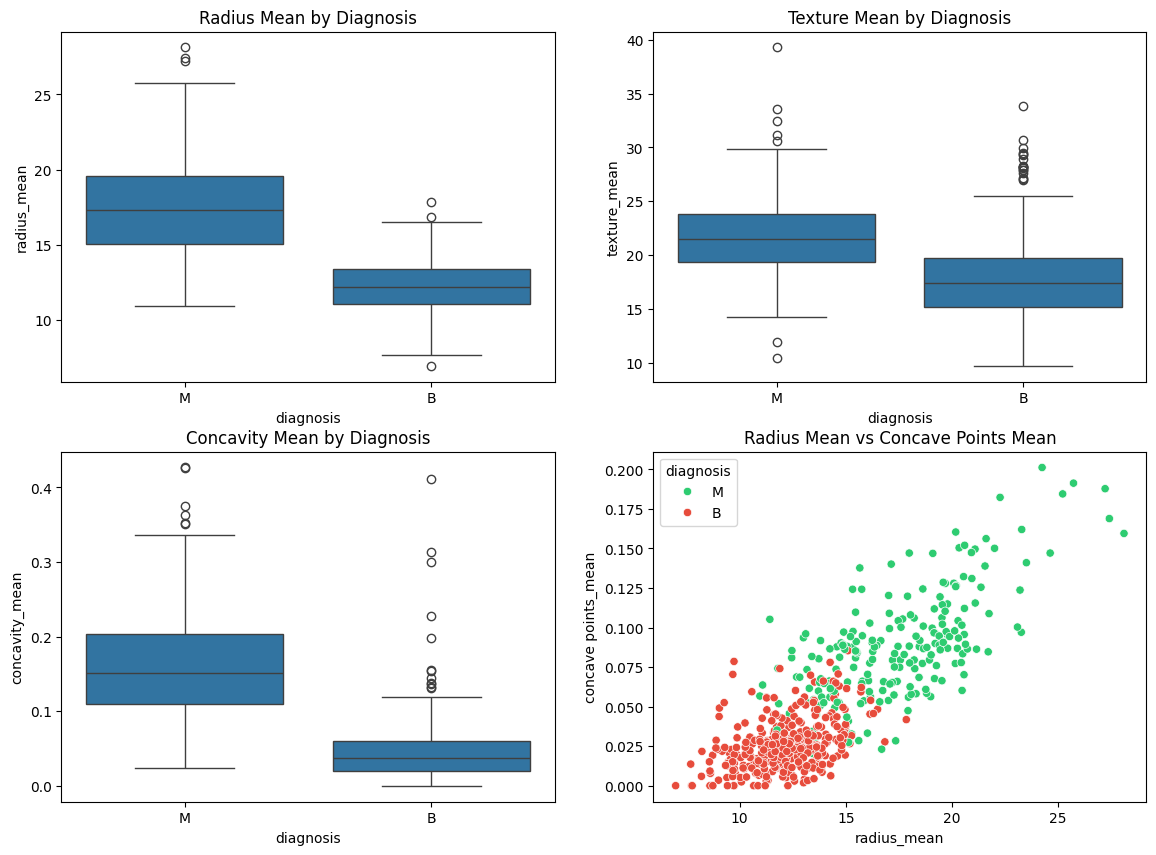

In [52]:
# EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='diagnosis', y='radius_mean', data=df, ax=axes[0,0])
axes[0,0].set_title('Radius Mean by Diagnosis')

sns.boxplot(x='diagnosis', y='texture_mean', data=df, ax=axes[0,1])
axes[0,1].set_title('Texture Mean by Diagnosis')

sns.boxplot(x='diagnosis', y='concavity_mean', data=df, ax=axes[1,0])
axes[1,0].set_title('Concavity Mean by Diagnosis')

sns.scatterplot(x='radius_mean', y='concave points_mean', hue='diagnosis',
                 data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1,1])
axes[1,1].set_title('Radius Mean vs Concave Points Mean')

plt.show()

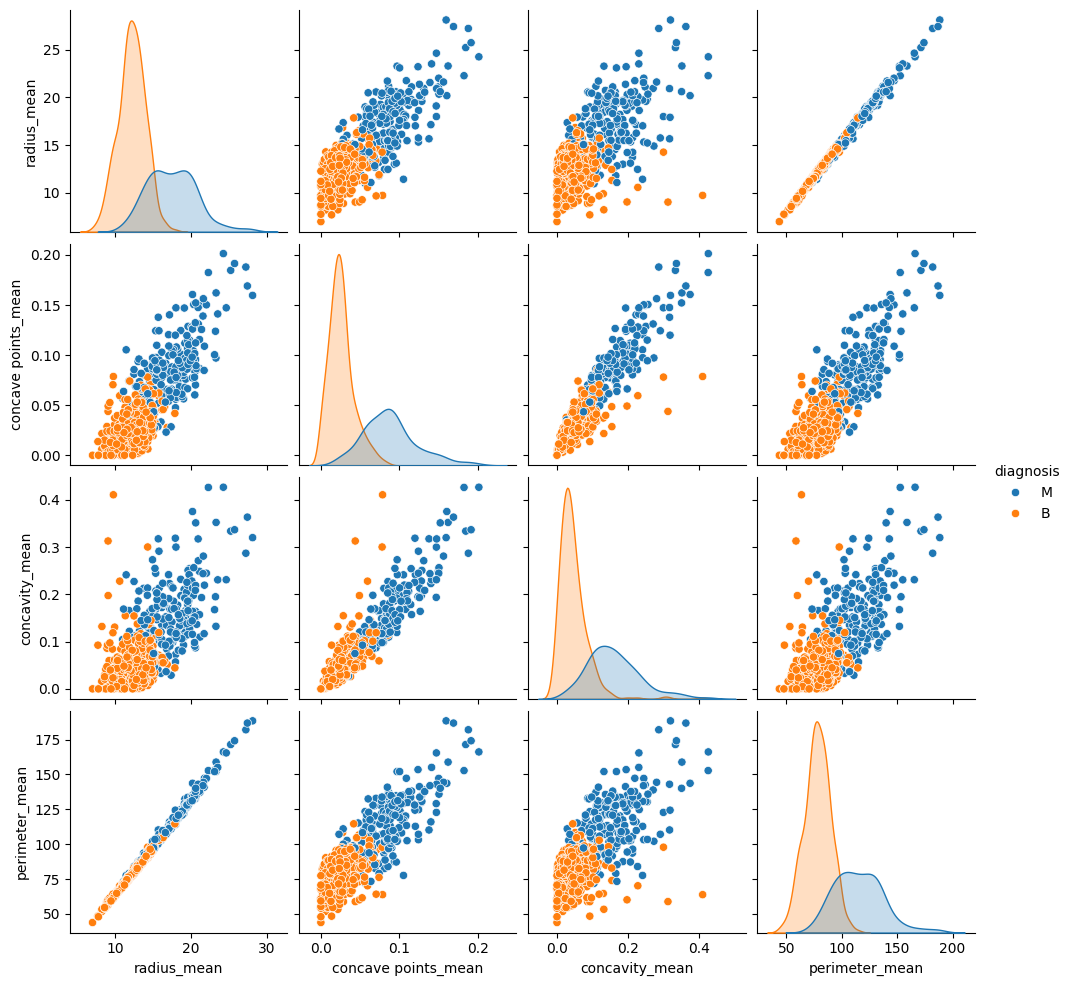

In [53]:
subset_cols = ['radius_mean', 'concave points_mean', 'concavity_mean', 'perimeter_mean', 'diagnosis']
sns.pairplot(df[subset_cols], hue='diagnosis')
plt.show()

##Answer:





1. Features: 30 ( subtracting "id","diagnosis", and "unnamed: 32" column)
2. Classification because the target variable contains two discrete classes.
3. data points: 569
4. Only column "Unnamed: 32" has null values which i will drop later.
5. Mostly numerical columns and only one categorical column diagnosis
6. Yes i need to encode the "diagnosis" column as it has categorical values. Machine learning models requires numerical values
7. Correlation: perimeter_worst and
concave points_worst is strongly correlated and smoothness_se and fractal_dimension_mean is negatively correlated
8. EDA insights: malignant tumors show noticeably higher radius, texture, and
concavity than benign ones, with fairly good separability between classes.

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [54]:
print(df.shape)
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)
print(df.shape)

(569, 33)
(569, 31)


In [55]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [56]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


## Preprocessing steps applied:
1. Dropped 'id' - a unique identifier carries no predictive signal
2. Dropped 'Unnamed: 32' - 100% missing values
3. Encoded 'diagnosis' from string ('M'/'B') to numeric (1/0) since models
   require numeric targets.
4. Checked for duplicate rows - none found.
5. Scaling will be done later

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



In [57]:
# features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Feature shape: (569, 30)
Target shape: (569,)
Training samples: (455, 30)
Testing samples : (114, 30)


Removed the id column because it is only an identifier.

Removed the Unnamed: 32 column because it contains only null values.

Kept all 30 numerical features since they are relevant for predicting breast cancer.

Encoded the diagnosis column into numerical labels (B = 0, M = 1).

Split the dataset into 80% training and 20% testing using train_test_split(), with stratify=y to maintain the same proportion of benign and malignant cases in both sets.

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [58]:
pipe_lr=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('lr_model',LogisticRegression(max_iter=1000,random_state=42))
    ]
)

pipe_lr

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr_model',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [59]:
pipe_rf=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('rf_model',RandomForestClassifier(n_estimators=200,random_state=42))
    ]
)
pipe_rf

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf_model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [60]:
pipe_lr.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr_model',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [61]:
pipe_rf.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf_model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [62]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

In [63]:
y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

pre_lr = precision_score(y_test, y_pred_lr)
pre_rf = precision_score(y_test, y_pred_rf)

rec_lr = recall_score(y_test, y_pred_lr)
rec_rf = recall_score(y_test, y_pred_rf)

print("Logistic Regression")
print("Accuracy :", acc_lr)
print("Precision:", pre_lr)
print("Recall   :", rec_lr)

print("\nRandom Forest")
print("Accuracy :", acc_rf)
print("Precision:", pre_rf)
print("Recall   :", rec_rf)

Logistic Regression
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286

Random Forest
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048


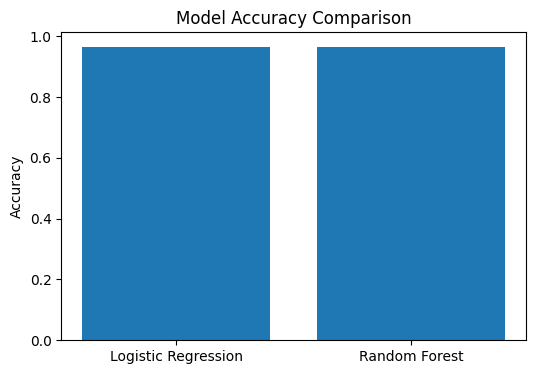

In [64]:
models = ['Logistic Regression', 'Random Forest']
accuracy = [acc_lr, acc_rf]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [65]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[acc_lr,acc_rf],
    'Precision':[pre_lr,pre_rf],
    'Recall':[rec_lr,rec_rf]
})

print(comparison)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.964912      0.975  0.928571
1        Random Forest  0.964912      1.000  0.904762


In [66]:
print("Lr confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Lr confusion Matrix
[[71  1]
 [ 3 39]]


In [67]:
print("RF confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

RF confusion Matrix
[[72  0]
 [ 4 38]]


In [68]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Both models achieved the same overall accuracy (96%) and F1-score (0.96), demonstrating excellent performance on the breast cancer dataset.

However, there are slight differences in their behavior:

Random Forest achieved 100% precision for malignant tumors, indicating that all tumors predicted as malignant were indeed malignant. This reduces false positive diagnoses.
Logistic Regression achieved a higher recall (93%) for malignant tumors compared to Random Forest (90%). This means it detected more actual cancer cases and produced fewer false negatives.

Since detecting malignant tumors is the primary objective in breast cancer diagnosis, Logistic Regression may be considered the more suitable model for this dataset, despite both models having the same overall accuracy. Missing a malignant case is generally more critical than incorrectly predicting a benign case as malignant.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [69]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [70]:
X_unsup = df.drop("diagnosis", axis=1)

scaler = StandardScaler()
X_scale = scaler.fit_transform(X_unsup)

In [71]:
pca=PCA(n_components=0.98,random_state=42)

X_pca=pca.fit_transform(X_scale)

print("Original shape:", X_scale.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original shape: (569, 30)
Reduced shape: (569, 14)
Explained variance: 0.9833502905469195


In [72]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

In [73]:
from sklearn.metrics import accuracy_score

acc1 = accuracy_score(y, clusters)
acc2 = accuracy_score(y, 1-clusters)

cluster_acc = max(acc1, acc2)

print("Clustering Accuracy:", cluster_acc)

Clustering Accuracy: 0.9068541300527241


### The supervised learning models (LR and RF) performed better than the unsupervised K-Means model.
Supervised learning uses the diagnosis labels during training, allowing the model to learn the relationship between the features and the target variable.
K-Means does not know which samples are malignant or benign. It only groups samples based on feature similarity.
The breast cancer dataset contains labeled examples, making supervised learning more suitable for accurate prediction.

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

### 8. Self Reflection on this Machine Learning Course

The hardest topic for me was feature engineering and model selection because choosing the right features and the most suitable algorithm requires understanding the dataset and comparing different models. This is important in real-world applications like medical diagnosis, where selecting the right model can improve prediction accuracy.

The easiest topic for me was Exploratory Data Analysis (EDA). Using charts and correlation heatmaps made it easy to understand the data and discover useful patterns before training the models. EDA is widely used in business and healthcare to gain insights from data.

Overall, this course helped me understand the complete machine learning workflow, from data preprocessing to model evaluation, and improved my practical skills in solving real-world problems.
